In [2]:
import numpy as np
import OpenEXR
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

In [3]:
def read_exr_rgb(path):
    with OpenEXR.File(path) as exr:
        part = exr.parts[0]
        channels = part.channels
        rgb = channels["RGBA"].pixels[..., :3].astype(np.float32)
    return rgb

In [4]:
def reinhard_tonemap(img):
    return img / (1.0 + img)

def linear_to_srgb(img):
    img = np.maximum(img, 0.0)
    return np.where(
        img <= 0.0031308,
        12.92 * img,
        1.055 * np.power(img, 1.0 / 2.2) - 0.055
    )

In [5]:
def get_blocks(img):
    blocks = []
    
    for i in range (0, 20):
        block = img[starting_y:starting_y+x_step, starting_x+(i*x_step):starting_x+(i+1)*x_step]
        blocks.append(block)

    return blocks

In [6]:
path1 = r"D:\ThesisData\dummy-6am-480\color"
path1 = Path(path1)

In [7]:
path2 = r"D:\ThesisData\dummy-6am-480\color1"
path2 = Path(path2)

In [8]:
y, x, c = 1080, 1920, 3

x_step = x//24
starting_x = 2 * x_step

starting_y = y//2-x_step//2

In [7]:
counter = 0
overall = 0

for file in path1.glob("*.exr"):
    name = file.name
    file2 = path2 / name

    img1 = read_exr_rgb(str(file))
    img2 = read_exr_rgb(str(file2))
    
    blocks1 = get_blocks(img1)
    blocks2 = get_blocks(img2)

    grvi_means1 = []
    grvi_means2 = []
    
    for i in range (len(blocks1)):

        b1 = blocks1[i]
        r1 = b1[:, :, 0]
        g1 = b1[:, :, 1]

        b2 = blocks2[i]
        r2 = b2[:, :, 0]
        g2 = b2[:, :, 1]
        
        g_rect1 = (g1 * np.pi) /  1020.232214
        r_rect1 = (r1 * np.pi) / 1130.973355

        g_rect2 = (g2 * np.pi) /  1020.232214 
        r_rect2 = (r2 * np.pi) / 1130.973355

        grvi1 = (g_rect1-r_rect1) / (g_rect1+r_rect1+0.000001)
        grvi_means1.append(grvi1.mean())

        grvi2 = (g_rect2-r_rect2) / (g_rect2+r_rect2+0.000001)
        grvi_means2.append(grvi2.mean())


    per = (np.abs(np.array(grvi_means1) - np.array(grvi_means2)) / np.maximum((np.abs(grvi_means1) + np.abs(grvi_means2)) / 2, 1e-8)) * 100
    counter = counter + 1
    overall = overall + per

    if counter == 151:
        break

final = overall / counter
final

array([65.0131   , 64.02129  , 63.12048  , 61.24281  , 58.68461  ,
       57.45892  , 54.861237 , 50.148033 , 46.000584 , 38.75445  ,
       35.183548 , 27.20817  , 20.564766 , 16.294832 , 11.38119  ,
        6.992726 ,  5.6798697,  6.422402 ,  8.329673 , 12.493694 ],
      dtype=float32)

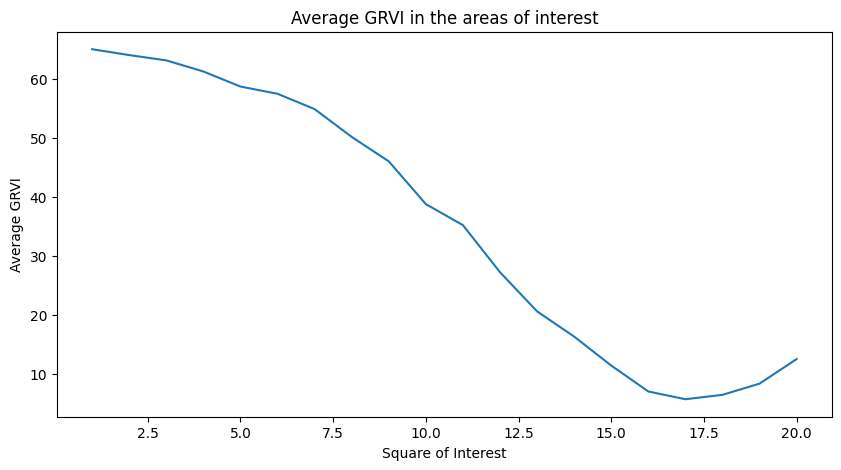

In [9]:
x = list(range(1, len(final) + 1))

plt.figure(figsize=(10, 5))
plt.plot(x, final)
plt.xlabel("Square of Interest")
plt.ylabel("Average GRVI")
plt.title("Average GRVI in the areas of interest")

plt.show()

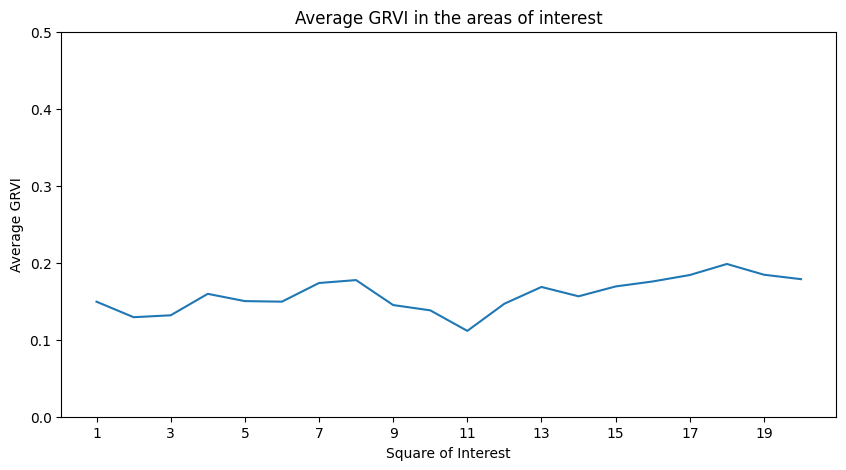

In [34]:
imgpath = r"C:\Users\sol77\Desktop\024.EXR"
img = read_exr_rgb(imgpath)

blocks = get_blocks(img)

grvi_means = []

for i in range (0, 20):

    
    b = blocks[i]
    r = b[:, :, 0]
    g = b[:, :, 1]

            
    g_rect = (g * np.pi) /  1020.232214
    r_rect = (r * np.pi) / 1334.39148

    grvi = (g_rect-r_rect) / (g_rect+r_rect+0.000001)
    grvi_means.append(grvi.mean())

x = list(range(1, 20 + 1))

plt.figure(figsize=(10, 5))
plt.plot(x, grvi_means)
plt.xlabel("Square of Interest")
plt.ylabel("Average GRVI")

plt.xticks(range(1, len(grvi_means) + 1, 2))
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])

plt.title("Average GRVI in the areas of interest")

plt.savefig("12_graph_24GRVI.png", dpi=100, bbox_inches="tight")
plt.show()

In [35]:
per = (grvi_means[0] - grvi_means[19]) / (np.maximum(grvi_means[19], 1e-8)) * 100
per

np.float32(-16.365381)

In [36]:
grvi_means[19]

np.float32(0.17863715)

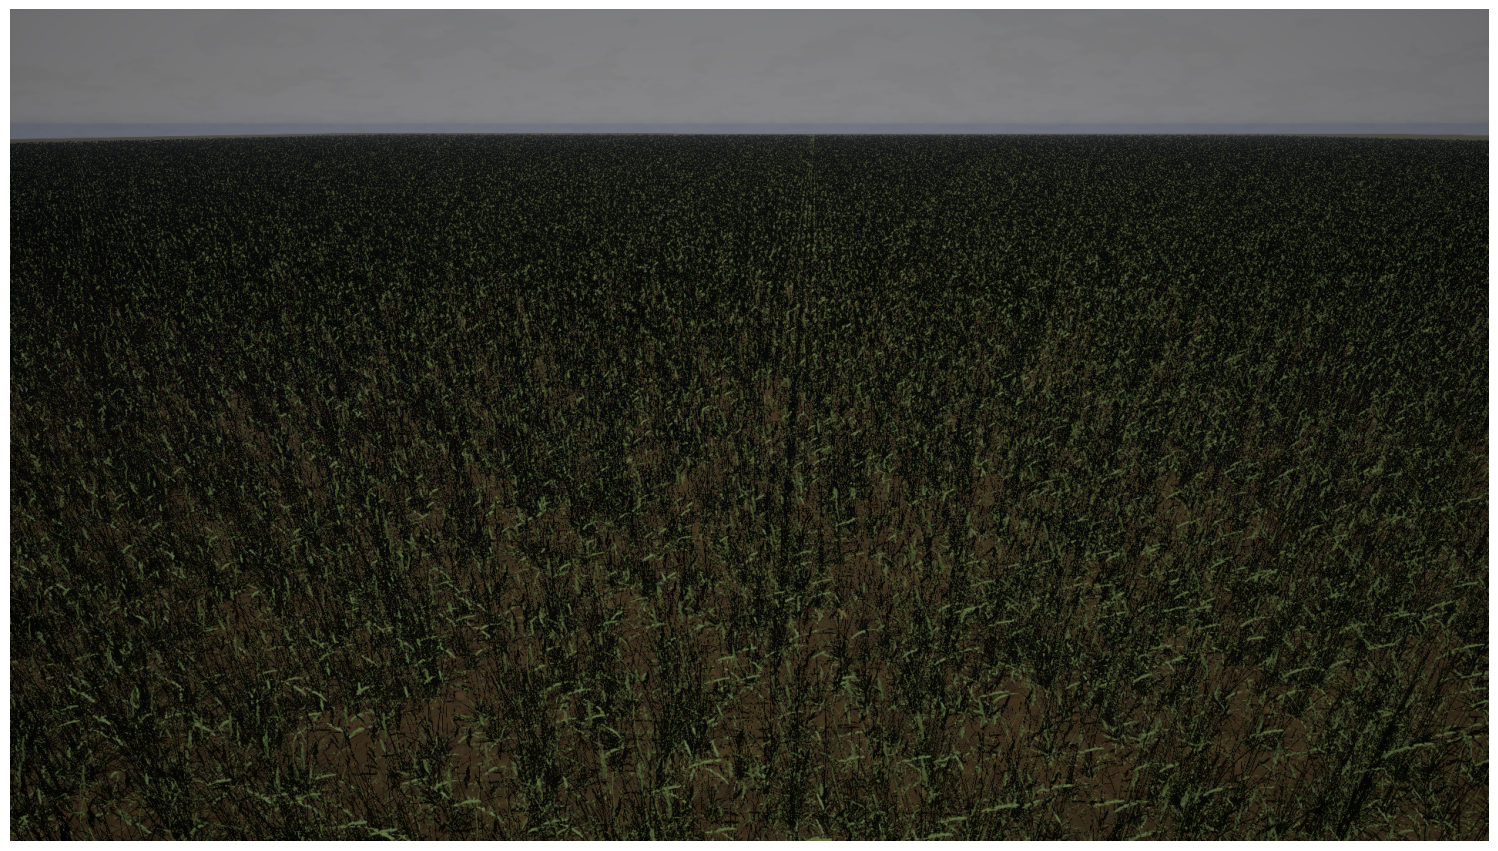

In [37]:
img_tm = reinhard_tonemap(img)
img_disp = linear_to_srgb(img_tm)
img_disp = np.clip(img_disp, 0.0, 1.0)
img_u8 = (img_disp * 255.0).round().astype(np.uint8)

plt.figure(figsize=(19.2, 10.8))
plt.imshow(img_u8, cmap="gray")
plt.axis("off")

plt.show()

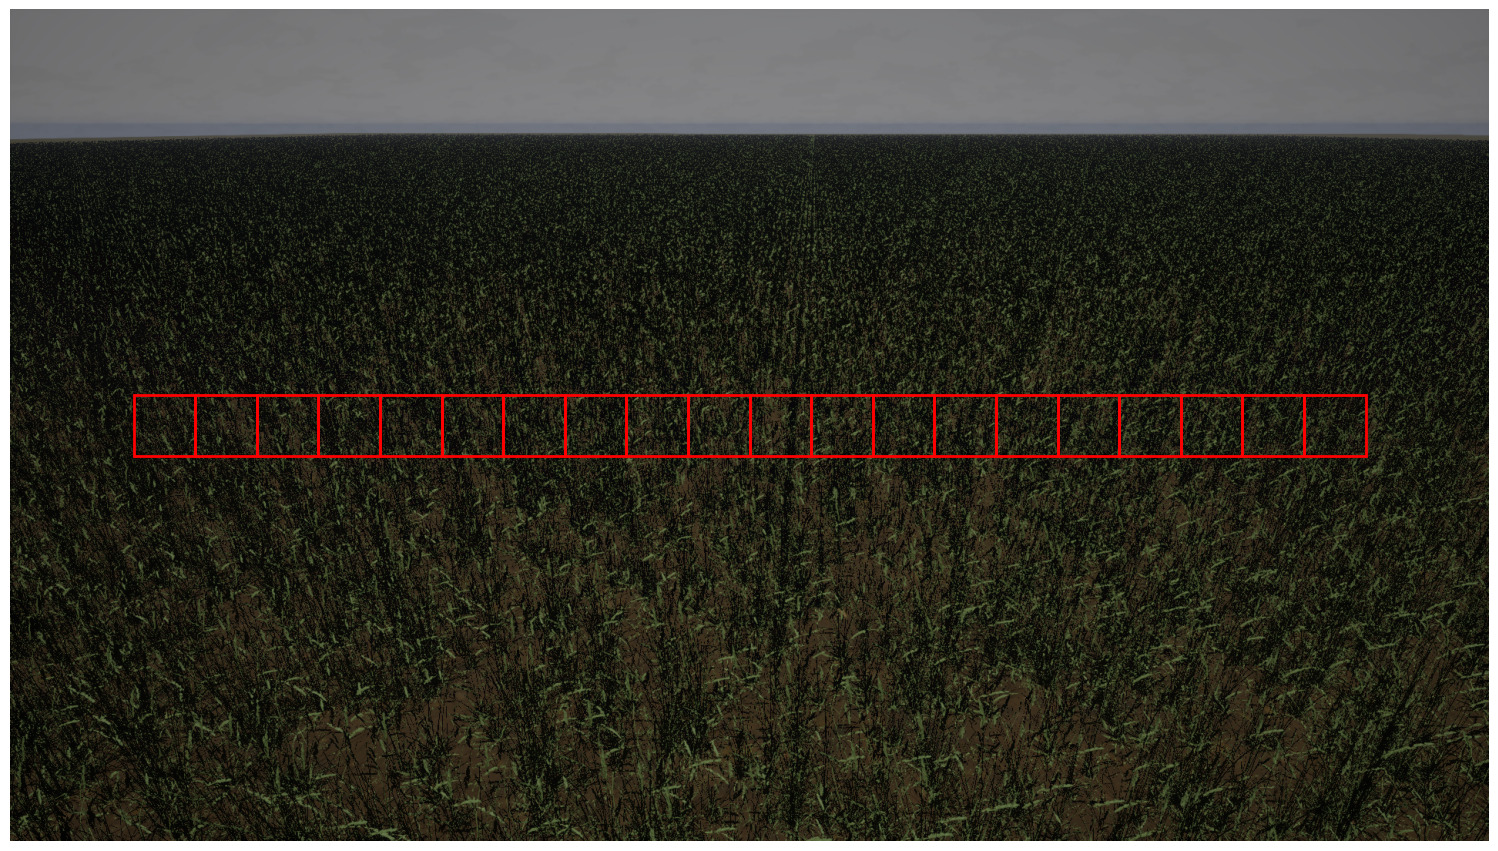

In [38]:
fig, ax = plt.subplots(figsize=(19.2, 10.8))
ax.imshow(img_u8)

for i in range (0, 20):
    rect = patches.Rectangle(
        (starting_x + (i*x_step), starting_y),
        x_step,
        x_step,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.axis("off")
plt.savefig("12_img_24GRVI.png", dpi=100, bbox_inches="tight")
plt.show()